In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


# Load and Inspect Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


1. charges is the target col
2. age, bmi, children - numeric columns
3. sex, smoker, region - categorical columns
4. no missing values
5. For numeric columns - Standard Scaling
6. For categorical columns - OHE.

smoker is basically a yes/no column. which encoding to use ? OHE and why ?


# Univariate Analysis

In [6]:
df['charges'].skew()

np.float64(1.5158796580240388)

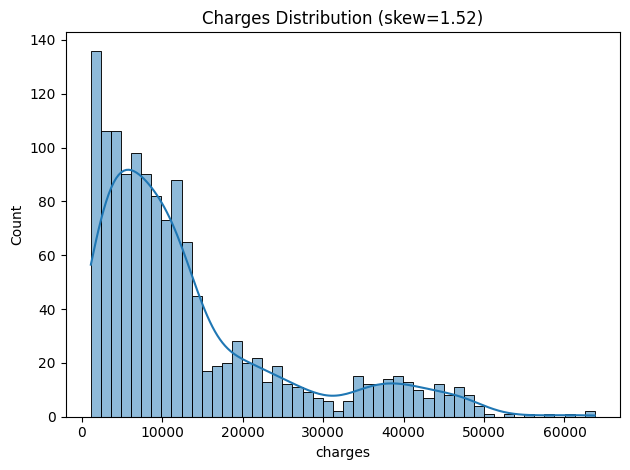

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['charges'], bins=50, kde= True)
plt.title(f"Charges Distribution (skew={df['charges'].skew():.2f})")
plt.tight_layout()

plt.show()

So its skewed. We will log transform the target column.

In [8]:
df['charges_log'] = np.log1p(df['charges'])

In [9]:
df['charges_log'].skew()

np.float64(-0.08981728740026822)

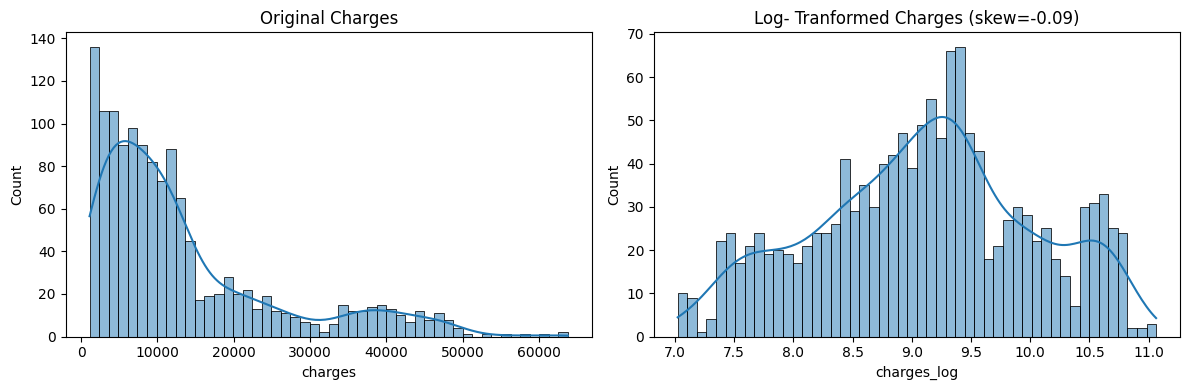

In [10]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['charges'], bins=50, ax=ax[0], kde=True)
ax[0].set_title('Original Charges')

sns.histplot(df['charges_log'], bins=50, ax=ax[1], kde=True)
ax[1].set_title(f"Log- Tranformed Charges (skew={df['charges_log'].skew():.2f})")

plt.tight_layout()
plt.show()


In [11]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
print(numeric_cols.skew().sort_values(ascending=False))

charges        1.515880
children       0.938380
bmi            0.284047
age            0.055673
charges_log   -0.089817
dtype: float64


In [12]:
categorical_cols = df.select_dtypes(include=['object'])
categorical_cols

for col in categorical_cols:
    print(col, ':', df[col].nunique(), 'unique values')
    print(df[col].value_counts(normalize=True))
    print()

sex : 2 unique values
sex
male      0.505232
female    0.494768
Name: proportion, dtype: float64

smoker : 2 unique values
smoker
no     0.795217
yes    0.204783
Name: proportion, dtype: float64

region : 4 unique values
region
southeast    0.272048
southwest    0.242900
northwest    0.242900
northeast    0.242152
Name: proportion, dtype: float64



Observation:

1. All three categorical columns show healthy distribution across their categories, with no single value dominating (99%), none of these are near-zero-variance drop candidates.
2. Numeric columns we can see children column is mildly skewed.

## Outlier Check

bmi: 9 outliers
charges: 139 outliers
age: 0 outliers


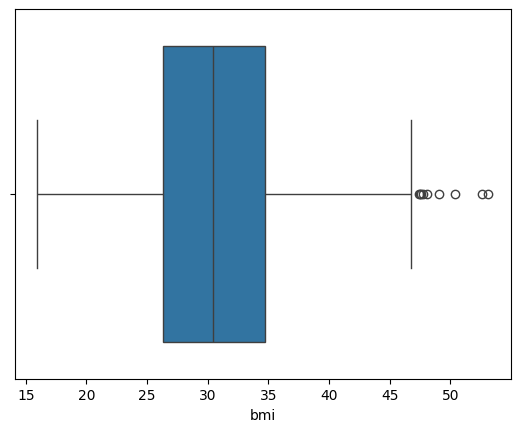

In [13]:
for col in ["bmi", "charges", "age"]:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

sns.boxplot(x=df["bmi"])
plt.show()

In [14]:
print(df.sort_values("bmi", ascending=False)[["bmi","smoker","charges"]].head(10))

        bmi smoker      charges
1317  53.13     no   1163.46270
1047  52.58    yes  44501.39820
847   50.38     no   2438.05520
116   49.06     no  11381.32540
286   48.07     no   9432.92530
1088  47.74     no   9748.91060
860   47.60    yes  46113.51100
401   47.52     no   8083.91980
543   47.41    yes  63770.42801
438   46.75     no  12592.53450


In [15]:
outlier_charges = df[df["charges"] > df["charges"].quantile(0.75) + 1.5*(df["charges"].quantile(0.75)-df["charges"].quantile(0.25))]
print(outlier_charges["smoker"].value_counts(normalize=True))

smoker
yes    0.978417
no     0.021583
Name: proportion, dtype: float64


139 "outliers" (10.4% of rows) is too many to be data errors — this is exactly the natural long right-tail we already fixed via log-transform. Cross-checking against smoker status confirms whether this tail is explained by a real, known driver (it almost certainly is) rather than corrupted data.

# Multivariate Analysis

## Correlation between numeric cols and target

In [16]:
numeric_cols = df.drop(columns=["charges", "charges_log"]).select_dtypes(include=['int64','float64']).columns.tolist()

correlations = df[numeric_cols + ["charges", "charges_log"]].corr()[["charges", "charges_log"]]
print(correlations)

              charges  charges_log
age          0.299008     0.527807
bmi          0.198341     0.132678
children     0.067998     0.161317
charges      1.000000     0.892996
charges_log  0.892996     1.000000


Observation 

1. Age is a strong predictor of insurance charges followed by children and bmi.
2. bmi is only 0.13 - we will investigate whether its drop worthy.

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[numeric_cols].dropna()
vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    index=numeric_cols
)
print(vif.sort_values(ascending=False))

bmi         7.846515
age         7.536550
children    1.796637
dtype: float64


Observation 

1. bmi and age show VIF of 7.5+ and bmi contributes 0.13
2. Should we drop bmi ?
3. Investigate age and bmi correlation

In [18]:
print(df[['bmi', 'age']].corr())

          bmi       age
bmi  1.000000  0.109272
age  0.109272  1.000000


Observation:

1. bmi and age is not strongly correlated so we cannot drop bmi.

## Categorical features vs charges (boxplot + ANOVA)

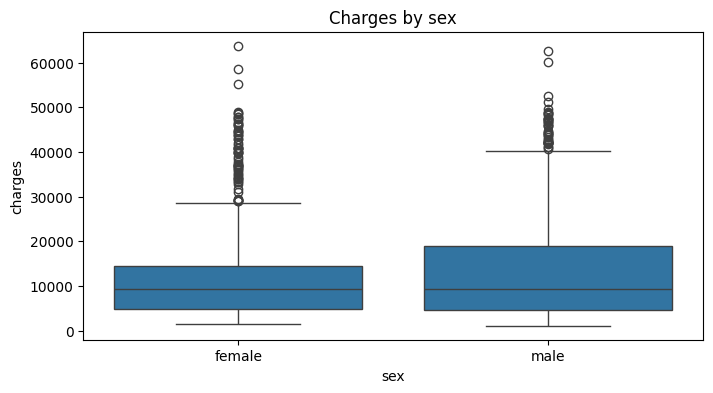

sex: F=4.400, p=0.0361


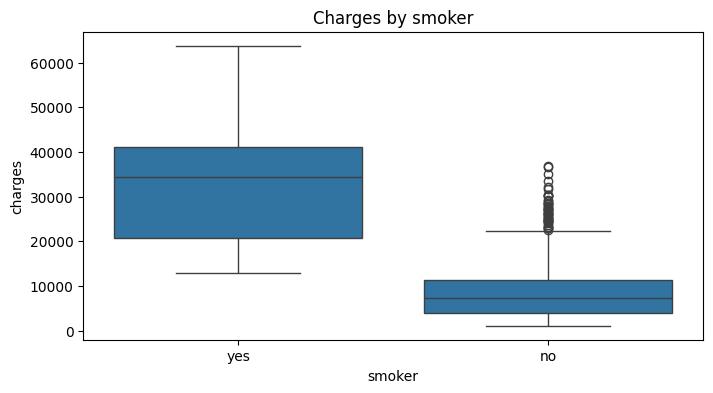

smoker: F=2177.615, p=0.0000


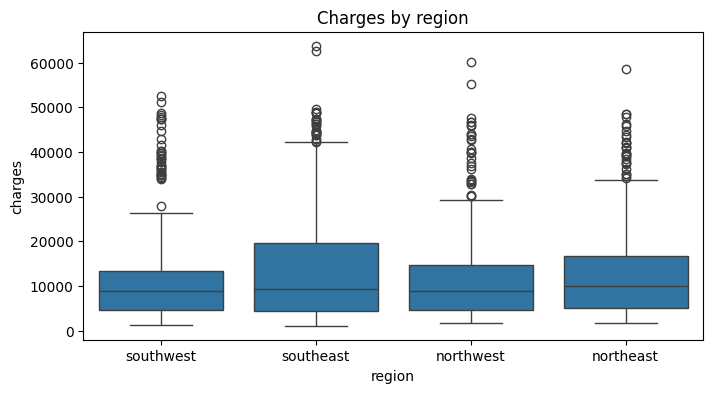

region: F=2.970, p=0.0309


In [19]:
from scipy import stats

for col in ["sex", "smoker", "region"]:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y="charges", data=df)
    plt.title(f"Charges by {col}")
    plt.show()

    groups = [g["charges"].values for _, g in df.groupby(col)]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"{col}: F={f_stat:.3f}, p={p_value:.4f}")

Statistical significance (p<0.05) tells you a difference is unlikely to be random noise — it doesn't tell you the difference is large or practically important. With 1338 rows, even a tiny, real-but-small effect (sex, region) can reach statistical significance. Smoker's F-value being ~500x larger confirms its effect is not just "detectable" but genuinely dominant — while sex and region are real, but comparatively negligible.

# Feature Engineering

In [20]:
df["smoker_bmi_interaction"] = (df["smoker"] == "yes").astype(int) * df["bmi"]


# df["bmi_category"] = pd.cut(df["bmi"], bins=[0,18.5,25,30,100], 
#                               labels=["Underweight","Normal","Overweight","Obese"])

In [21]:
print(df[["smoker_bmi_interaction","charges_log"]].corr())

                        smoker_bmi_interaction  charges_log
smoker_bmi_interaction                1.000000     0.683018
charges_log                           0.683018     1.000000


smoker_bmi_interaction's 0.683 correlation with charges_log — stronger than age alone — confirms this engineered feature captures real, powerful signal.

In [22]:
X_check = df[["age","bmi","children","smoker_bmi_interaction"]]
from statsmodels.tools.tools import add_constant
X_with_const = add_constant(X_check)
vif = pd.Series([variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])], index=X_with_const.columns)
print(vif)

const                     31.955065
age                        1.014782
bmi                        1.024867
children                   1.001912
smoker_bmi_interaction     1.012955
dtype: float64


# Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['charges', 'charges_log'])
y = df['charges_log']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

# Encoding and Scaling

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("nominal", OneHotEncoder(handle_unknown="ignore", drop="first"), ["sex", "smoker", "region"]),
        ("scale", StandardScaler(), ["age", "bmi", "children","smoker_bmi_interaction"])
    ]
)

# Pipeline

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

In [26]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker', 'region']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'bmi', 'children',
                                                   'smoker_bmi_interaction'])])),
                ('model', LinearRegression())])

# Predict and evaluate

In [27]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

predictions_log = full_pipeline.predict(X_test)
predictions_real = np.expm1(predictions_log)
y_test_real = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
r2 = r2_score(y_test_real, predictions_real)
print(f"RMSE: {rmse:.2f}, R²: {r2:.4f}")

RMSE: 8559.98, R²: 0.5280


In [28]:
preprocessor_v2 = ColumnTransformer(transformers=[
    ("nominal", OneHotEncoder(handle_unknown="ignore", drop="first"), ["sex", "region"]),  # smoker hataya
    ("scale", StandardScaler(), ["age", "bmi", "children", "smoker_bmi_interaction"])
])

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

full_pipeline_2 = Pipeline([
    ("preprocessing", preprocessor_v2),
    ("model", LinearRegression())
])

In [30]:
full_pipeline_2.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'region']),
                                                 ('scale', StandardScaler(),
                                                  ['age', 'bmi', 'children',
                                                   'smoker_bmi_interaction'])])),
                ('model', LinearRegression())])

In [31]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

predictions_log = full_pipeline_2.predict(X_test)
predictions_real = np.expm1(predictions_log)
y_test_real = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))
r2 = r2_score(y_test_real, predictions_real)
print(f"RMSE: {rmse:.2f}, R²: {r2:.4f}")

RMSE: 8774.76, R²: 0.5040
